In [2]:
!pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
train_df = pd.read_csv("../data/raw/train.csv")
features_df = pd.read_csv("../data/raw/features.csv")
stores_df = pd.read_csv("../data/raw/stores.csv")

In [4]:
print(train_df.head())
print(features_df.head())
print(stores_df.head())

   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False
   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31       2.572        NaN        NaN   
1      1  2010-02-12        38.51       2.548        NaN        NaN   
2      1  2010-02-19        39.93       2.514        NaN        NaN   
3      1  2010-02-26        46.63       2.561        NaN        NaN   
4      1  2010-03-05        46.50       2.625        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  
0        NaN        NaN        NaN  211.096358         8.106      False  
1        NaN        NaN        NaN  211.242170         8.106       True  
2        NaN        NaN        NaN  211

In [5]:
print(train_df.shape)
print(features_df.shape)
print(stores_df.shape)

(421570, 5)
(8190, 12)
(45, 3)


In [6]:
train_df.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

In [7]:
features_df.isnull().sum()

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

In [8]:
stores_df.isnull().sum()

Store    0
Type     0
Size     0
dtype: int64

In [9]:
df = pd.merge(train_df, features_df, on =['Store', 'Date' , 'IsHoliday'])

In [10]:
df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667


In [11]:
df = pd.merge(df,stores_df, on='Store')

In [12]:
df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,B,118221
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,B,118221
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,B,118221
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,B,118221


In [13]:
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
df['Year']= df['Date'].dt.year
df['Month']= df['Date'].dt.month
df['Day']= df['Date'].dt.day
df['Week']=df['Date'].dt.isocalendar().week
df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Day,Week
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315,2010,2,5,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315,2010,2,12,6
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315,2010,2,19,7
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315,2010,2,26,8
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315,2010,3,5,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,B,118221,2012,9,28,39
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,B,118221,2012,10,5,40
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,B,118221,2012,10,12,41
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,B,118221,2012,10,19,42


In [15]:
total_sales = df['Weekly_Sales'].sum()
print(total_sales)

6737218987.110001


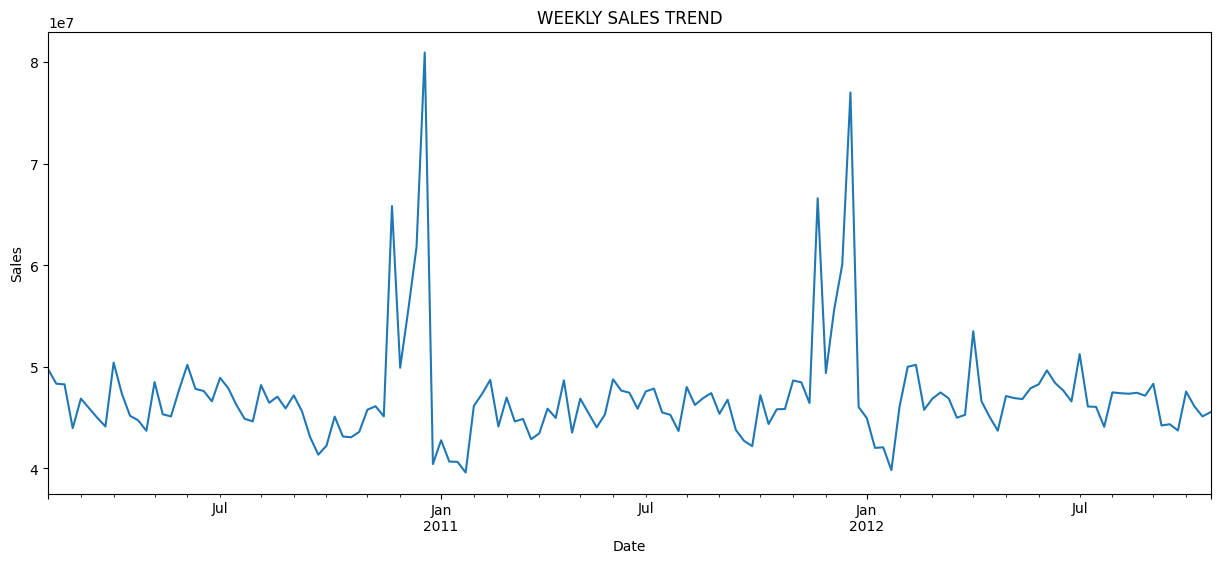

In [16]:
#weekly sales trend
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum()
plt.figure(figsize=(15,6))
weekly_sales.plot()
plt.title('WEEKLY SALES TREND')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

In [17]:
#holiday vs non holiday sales
holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean()
print(holiday_sales)

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64


In [18]:
#top performing stores
top_stores = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
top_stores.head(10)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64

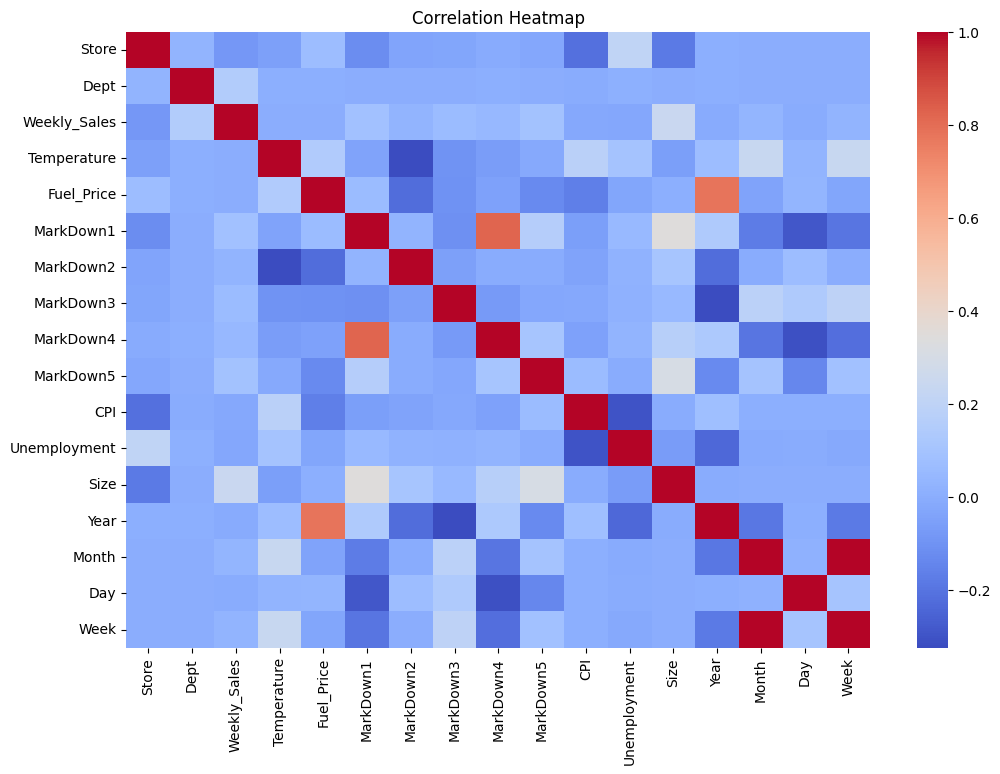

In [19]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_cols.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [20]:
df.isnull().sum().sort_values(ascending=False)

MarkDown2       310322
MarkDown4       286603
MarkDown3       284479
MarkDown1       270889
MarkDown5       270138
Date                 0
Dept                 0
Store                0
Weekly_Sales         0
Fuel_Price           0
IsHoliday            0
Temperature          0
CPI                  0
Unemployment         0
Type                 0
Size                 0
Year                 0
Month                0
Day                  0
Week                 0
dtype: int64

In [21]:
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

In [22]:
df.fillna(df.median(numeric_only=True),inplace=True)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Day,Week
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.00,0.00,0.00,0.00,0.00,211.096358,8.106,A,151315,2010,2,5,5
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.00,0.00,0.00,0.00,0.00,211.242170,8.106,A,151315,2010,2,12,6
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.00,0.00,0.00,0.00,0.00,211.289143,8.106,A,151315,2010,2,19,7
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.00,0.00,0.00,0.00,0.00,211.319643,8.106,A,151315,2010,2,26,8
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.00,0.00,0.00,0.00,0.00,211.350143,8.106,A,151315,2010,3,5,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,B,118221,2012,9,28,39
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,0.00,18.82,2253.43,2340.01,192.170412,8.667,B,118221,2012,10,5,40
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,0.00,7.89,599.32,3990.54,192.327265,8.667,B,118221,2012,10,12,41
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,0.00,3.18,437.73,1537.49,192.330854,8.667,B,118221,2012,10,19,42


In [23]:
df['Quarter'] = df['Date'].dt.quarter

In [24]:
df['weekend'] = df['Date'].dt.weekday >= 5
df['weekend'] = df['weekend'].astype(int)

In [25]:
df = df.sort_values(by=['Store','Dept','Date'])
df['Lag_1'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(1)

In [26]:
df['Lag_4'] = df.groupby(['Store','Dept'])['Weekly_Sales'].shift(4)

In [27]:
df.head(100)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Type,Size,Year,Month,Day,Week,Quarter,weekend,Lag_1,Lag_4
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.00,0.00,0.00,...,A,151315,2010,2,5,5,1,0,NaN,NaN
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.00,0.00,0.00,...,A,151315,2010,2,12,6,1,0,24924.50,NaN
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.00,0.00,0.00,...,A,151315,2010,2,19,7,1,0,46039.49,NaN
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.00,0.00,0.00,...,A,151315,2010,2,26,8,1,0,41595.55,NaN
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.00,0.00,0.00,...,A,151315,2010,3,5,9,1,0,19403.54,24924.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1,1,2011-12-02,25293.49,False,48.91,3.172,5629.51,68.00,1398.11,...,A,151315,2011,12,2,48,4,0,20911.25,39886.06
96,1,1,2011-12-09,33305.92,False,43.93,3.158,4640.65,19.00,105.02,...,A,151315,2011,12,9,49,4,0,25293.49,18689.54
97,1,1,2011-12-16,45773.03,False,51.63,3.159,5011.32,67.00,347.37,...,A,151315,2011,12,16,50,4,0,33305.92,19050.66
98,1,1,2011-12-23,46788.75,False,47.96,3.112,2725.36,40.48,634.70,...,A,151315,2011,12,23,51,4,0,45773.03,20911.25


In [28]:
#AVG of recent weeks(4) sales
df['Rolling_Mean_4'] = (
    df.groupby(['Store','Dept'])['Weekly_Sales']
    .transform(lambda x: x.shift(1).rolling(4).mean())
)

In [29]:
df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Size,Year,Month,Day,Week,Quarter,weekend,Lag_1,Lag_4,Rolling_Mean_4
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.00,0.00,0.00,...,151315,2010,2,5,5,1,0,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.00,0.00,0.00,...,151315,2010,2,12,6,1,0,24924.50,NaN,NaN
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.00,0.00,0.00,...,151315,2010,2,19,7,1,0,46039.49,NaN,NaN
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.00,0.00,0.00,...,151315,2010,2,26,8,1,0,41595.55,NaN,NaN
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.00,0.00,0.00,...,151315,2010,3,5,9,1,0,19403.54,24924.50,32990.7700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,...,118221,2012,9,28,39,3,0,467.30,346.04,442.9350
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,0.00,18.82,...,118221,2012,10,5,40,4,0,508.37,352.44,483.5175
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,0.00,7.89,...,118221,2012,10,12,41,4,0,628.10,605.96,552.4325
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,0.00,3.18,...,118221,2012,10,19,42,4,0,1061.02,467.30,666.1975


In [30]:
#STD of recent weeks(4) to find how unstable or fluctuating values are
df['Rolling_STD_4']=(
    df.groupby(['Store','Dept'])['Weekly_Sales']
    .transform(lambda x: x.shift(1).rolling(4).std())
)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 26 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Store           421570 non-null  int64         
 1   Dept            421570 non-null  int64         
 2   Date            421570 non-null  datetime64[us]
 3   Weekly_Sales    421570 non-null  float64       
 4   IsHoliday       421570 non-null  bool          
 5   Temperature     421570 non-null  float64       
 6   Fuel_Price      421570 non-null  float64       
 7   MarkDown1       421570 non-null  float64       
 8   MarkDown2       421570 non-null  float64       
 9   MarkDown3       421570 non-null  float64       
 10  MarkDown4       421570 non-null  float64       
 11  MarkDown5       421570 non-null  float64       
 12  CPI             421570 non-null  float64       
 13  Unemployment    421570 non-null  float64       
 14  Type            421570 non-null  str           

In [32]:
df.dropna(inplace=True)

In [33]:
df['IsHoliday'] = df['IsHoliday'].astype(int)

In [34]:
target = 'Weekly_Sales'


In [35]:
features = [
    'Store',
    'Dept',
    'IsHoliday',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'Size',
    'Year',
    'Month',
    'Week',
    'Quarter',
    'Lag_1',
    'Lag_4',
    'Rolling_Mean_4',
    'Rolling_STD_4'
]

In [36]:
#splitting appropriately not random_split
train = df[df['Date'] < '2012-01-01']
test = df[df['Date'] >= '2012-01-01']

In [37]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [38]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
preds = lr.predict(X_test)

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test,preds)

rmse = np.sqrt(mean_squared_error(y_test,preds))

print('MAE:',mae)
print('RMSE:',rmse)

MAE: 1830.9083401535495
RMSE: 3931.2252772071342


In [41]:
import sys
print(sys.executable)

C:\Users\Admin\walmart-sales-forecasting\venv\Scripts\python.exe


In [42]:
from xgboost import XGBRegressor

In [43]:
xgb_model = XGBRegressor(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth=6,
    random_state=42
)

In [44]:
xgb_model.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [45]:
xgb_preds = xgb_model.predict(X_test)

In [46]:
xgb_mae = mean_absolute_error(y_test, xgb_preds)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)

XGBoost MAE: 1507.5674411395387
XGBoost RMSE: 3286.3408403222793


In [47]:
comparision = pd.DataFrame({
    'Model' : ['Linear Regression','XGBoost'],
    'MAE': [mae, xgb_mae],
    'RMSE':[rmse, xgb_rmse]
})
comparision

,Model,MAE,RMSE
0,Linear Regression,1830.908340,3931.225277
1,XGBoost,1507.567441,3286.340840


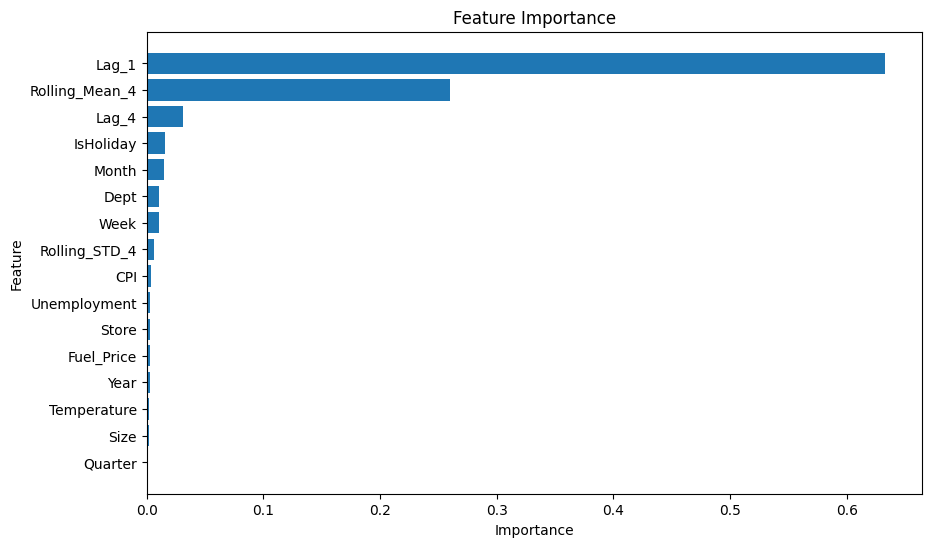

In [48]:
importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending = False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')

plt.gca().invert_yaxis() #normally, smallest feature o top so to switch to most important feature appears at top

plt.show()


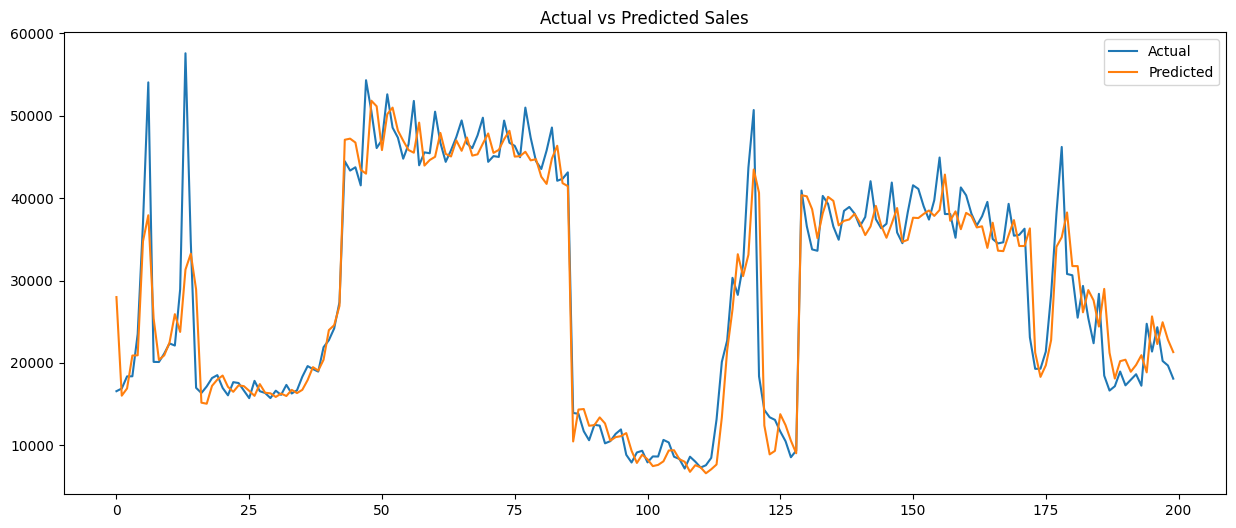

In [49]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.values[:200],
    label='Actual'
)

plt.plot(
    xgb_preds[:200],
    label = 'Predicted'
)
plt.legend()
plt.title('Actual vs Predicted Sales')
plt.show()

In [50]:
#hyperparameter tuning
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [51]:
xgb_model.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [52]:
xgb_preds = xgb_model.predict(X_test)

In [53]:
xgb_mae = mean_absolute_error(y_test, xgb_preds)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)

XGBoost MAE: 1455.3273710444455
XGBoost RMSE: 3116.5869720971855


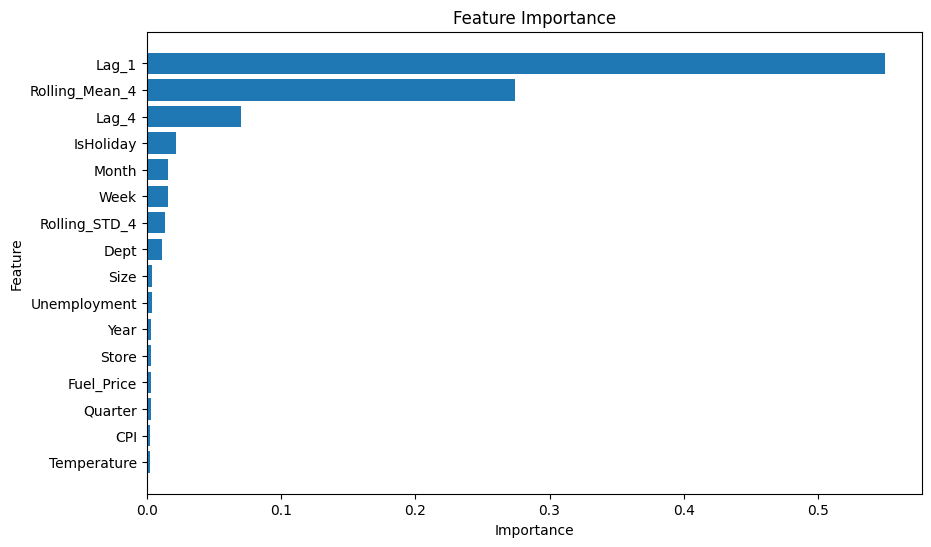

In [54]:
importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending = False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')

plt.gca().invert_yaxis() #normally, smallest feature o top so to switch to most important feature appears at top

plt.show()


In [55]:
#save model
import joblib
joblib.dump(xgb_model, "../models/xgboost_sales_forecast.pkl")

['../models/xgboost_sales_forecast.pkl']

In [56]:
test = test.copy()
test['Predicted_Sales'] = xgb_preds

In [57]:
def inventory_risk(pred):
    if pred > 30000:
        return 'High Demand'
    elif pred < 10000:
        return 'Low Demand'
    else:
        return 'Normal'

In [58]:
test['Inventory_Risk'] = test['Predicted_Sales'].apply(inventory_risk)

In [59]:
def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Spring"

    elif month in [6,7,8]:
        return "Summer"

    else:
        return "Fall"

In [60]:
test['Season'] = test['Month'].apply(get_season)

In [63]:
test.to_csv(
    "../data/processed/dashboard_data.csv",
    index = False
)